**Нейронная сеть прямого распространения для классификации** - это многослойная архитектура, где сигнал движется от входного слоя через скрытые слои к выходному слою с количеством нейронов, равным числу классов. Каждый нейрон скрытого слоя вычисляет взвешенную сумму входов и применяет нелинейную функцию активации ReLU. Выходной слой использует функцию активации softmax, преобразующую выходы в вероятности принадлежности к каждому классу.

## Используемые библиотеки

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

## Используемый датасет


Размер матрицы признаков: (70000, 784)
Количество примеров: 70000
Количество признаков: 784 (28×28 изображение)
Уникальные классы: [0 1 2 3 4 5 6 7 8 9]
Диапазон значений пикселей: [0, 255]



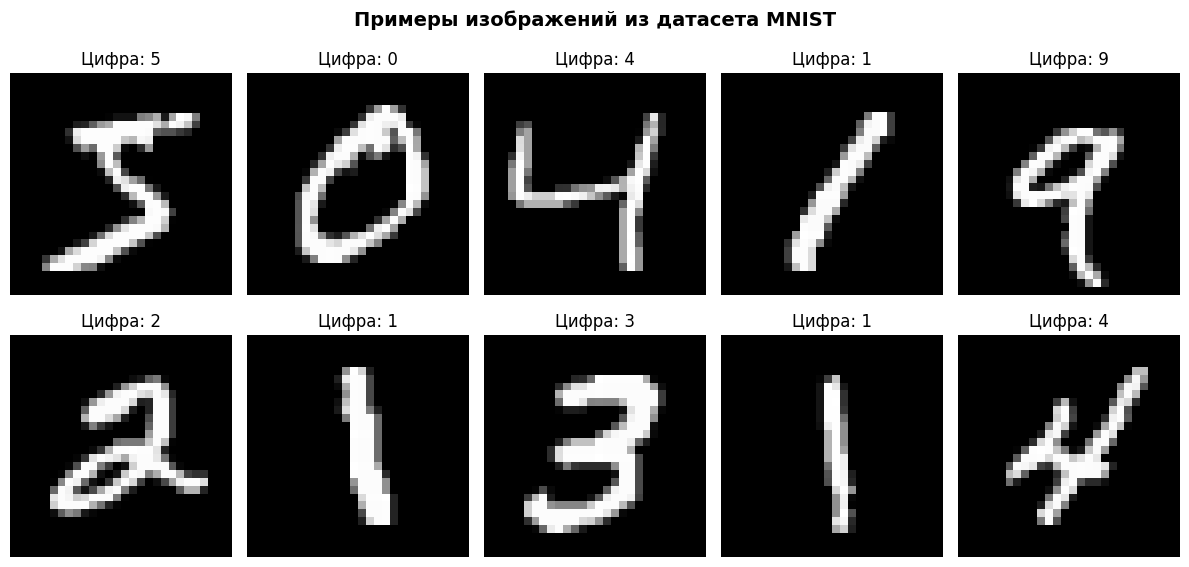

In [13]:
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data.values, mnist.target.astype(int).values

print(f"\nРазмер матрицы признаков: {X.shape}")
print(f"Количество примеров: {len(X)}")
print(f"Количество признаков: {X.shape[1]} (28×28 изображение)")
print(f"Уникальные классы: {np.unique(y)}")
print(f"Диапазон значений пикселей: [{X.min():.0f}, {X.max():.0f}]")
print()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Цифра: {y[i]}")
    axes[i].axis('off')

plt.suptitle("Примеры изображений из датасета MNIST", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Обработка датасета

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]} примеров")
print(f"Размер тестовой выборки: {X_test.shape[0]} примеров")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Размер обучающей выборки: 56000 примеров
Размер тестовой выборки: 14000 примеров


## Тепловая карта

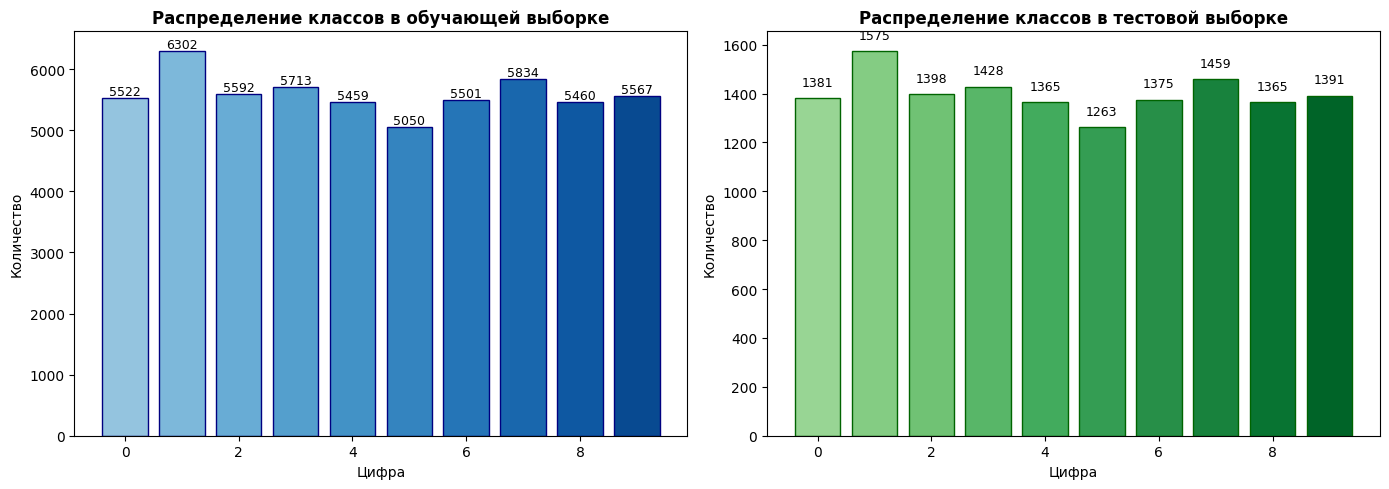

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique_train, counts_train = np.unique(y_train, return_counts=True)
colors_train = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
axes[0].bar(unique_train, counts_train, color=colors_train, edgecolor='navy')
axes[0].set_title('Распределение классов в обучающей выборке', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Цифра')
axes[0].set_ylabel('Количество')
for i, (digit, count) in enumerate(zip(unique_train, counts_train)):
    axes[0].text(digit, count + 50, str(count), ha='center', fontsize=9)

unique_test, counts_test = np.unique(y_test, return_counts=True)
colors_test = plt.cm.Greens(np.linspace(0.4, 0.9, 10))
axes[1].bar(unique_test, counts_test, color=colors_test, edgecolor='darkgreen')
axes[1].set_title('Распределение классов в тестовой выборке', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Цифра')
axes[1].set_ylabel('Количество')
for i, (digit, count) in enumerate(zip(unique_test, counts_test)):
    axes[1].text(digit, count + 50, str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Обучение модели

Iteration 1, loss = 0.28901204
Validation score: 0.955179
Iteration 2, loss = 0.09729575
Validation score: 0.963750
Iteration 3, loss = 0.05992655
Validation score: 0.968036
Iteration 4, loss = 0.03922678
Validation score: 0.967500
Iteration 5, loss = 0.03046991
Validation score: 0.970357
Iteration 6, loss = 0.02670429
Validation score: 0.964286
Iteration 7, loss = 0.02196619
Validation score: 0.970357
Iteration 8, loss = 0.02154288
Validation score: 0.968036
Iteration 9, loss = 0.02532194
Validation score: 0.970357
Iteration 10, loss = 0.01839405
Validation score: 0.972500
Iteration 11, loss = 0.01528292
Validation score: 0.971250
Iteration 12, loss = 0.00907906
Validation score: 0.971250
Iteration 13, loss = 0.00901743
Validation score: 0.971964
Iteration 14, loss = 0.01239459
Validation score: 0.971250
Iteration 15, loss = 0.01734119
Validation score: 0.973393
Iteration 16, loss = 0.01353681
Validation score: 0.973036
Iteration 17, loss = 0.01729278
Validation score: 0.968929
Iterat

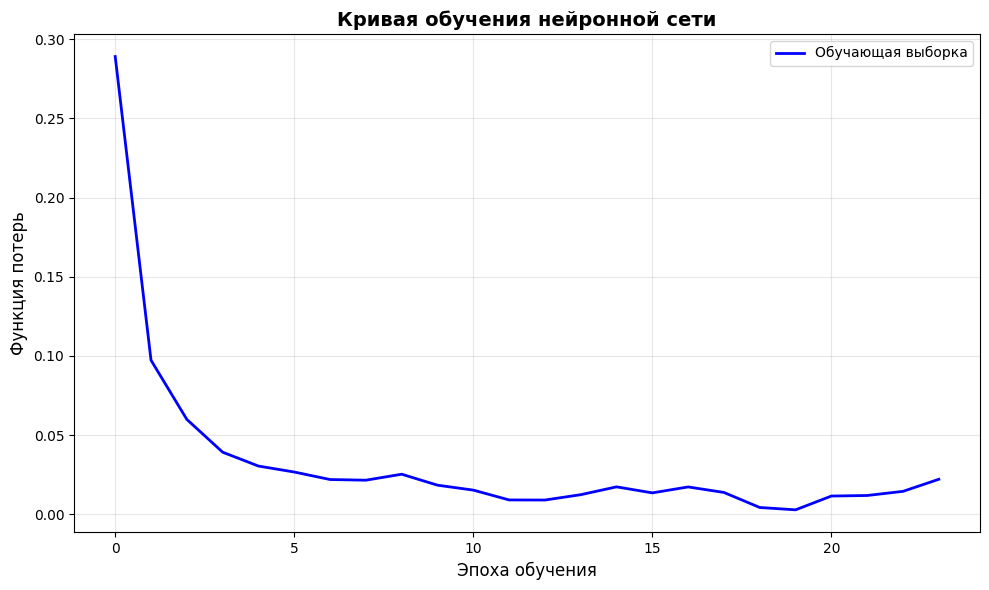

In [20]:
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=200,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=True
)

mlp_classifier.fit(X_train_scaled, y_train)

print(f"\nРЕЗУЛЬТАТЫ ОБУЧЕНИЯ:")
print(f"Количество выполненных эпох: {mlp_classifier.n_iter_}")
print(f"Финальное значение функции потерь: {mlp_classifier.loss_:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(mlp_classifier.loss_curve_, 'b-', linewidth=2, label='Обучающая выборка')
plt.xlabel('Эпоха обучения', fontsize=12)
plt.ylabel('Функция потерь', fontsize=12)
plt.title('Кривая обучения нейронной сети', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Прогнозы модели

Точность на тестовой выбоке: 0.9734 (97.34%)
Количество ошибок: 372 из 14000

Первые десять предсказаний:
------------------------------------------------------------
№     Истинно    Предсказано  Уверенность 
------------------------------------------------------------
1     7          7            1.0000
2     3          3            1.0000
3     1          1            1.0000
4     1          1            0.9999
5     2          2            1.0000
6     5          5            1.0000
7     9          9            1.0000
8     8          3            0.7904
9     8          8            1.0000
10    1          1            1.0000
------------------------------------------------------------


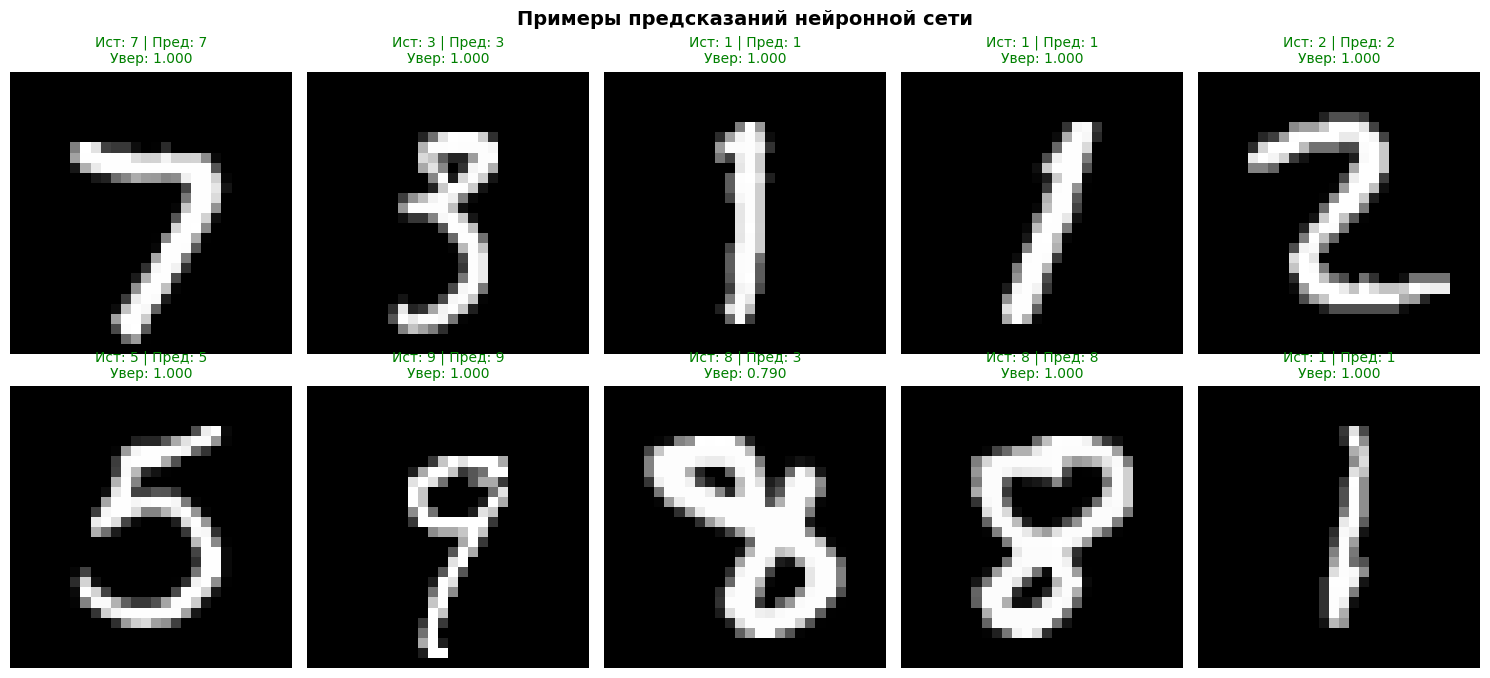

In [25]:
mlp_predictions = mlp_classifier.predict(X_test_scaled)
mlp_proba = mlp_classifier.predict_proba(X_test_scaled)

mlp_accuracy = accuracy_score(y_test, mlp_predictions)

print(f"Точность на тестовой выбоке: {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)")
print(f"Количество ошибок: {(y_test != mlp_predictions).sum()} из {len(y_test)}")

print("\nПервые десять предсказаний:")
print("-" * 60)
print(f"{'№':<5} {'Истинно':<10} {'Предсказано':<12} {'Уверенность':<12}")
print("-" * 60)
for i in range(10):
    true_label = y_test[i]
    pred_label = mlp_predictions[i]
    confidence = mlp_proba[i][pred_label]
    print(f"{i+1:<5} {true_label:<10} {pred_label:<12} {confidence:.4f}")
print("-" * 60)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    true_label = y_test[i]
    pred_label = mlp_predictions[i]
    confidence = mlp_proba[i][pred_label]
    axes[i].set_title(f"Ист: {true_label} | Пред: {pred_label}\nУвер: {confidence:.3f}", fontsize=10, color='green')
    axes[i].axis('off')

plt.suptitle("Примеры предсказаний нейронной сети",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Графики выходных результатов

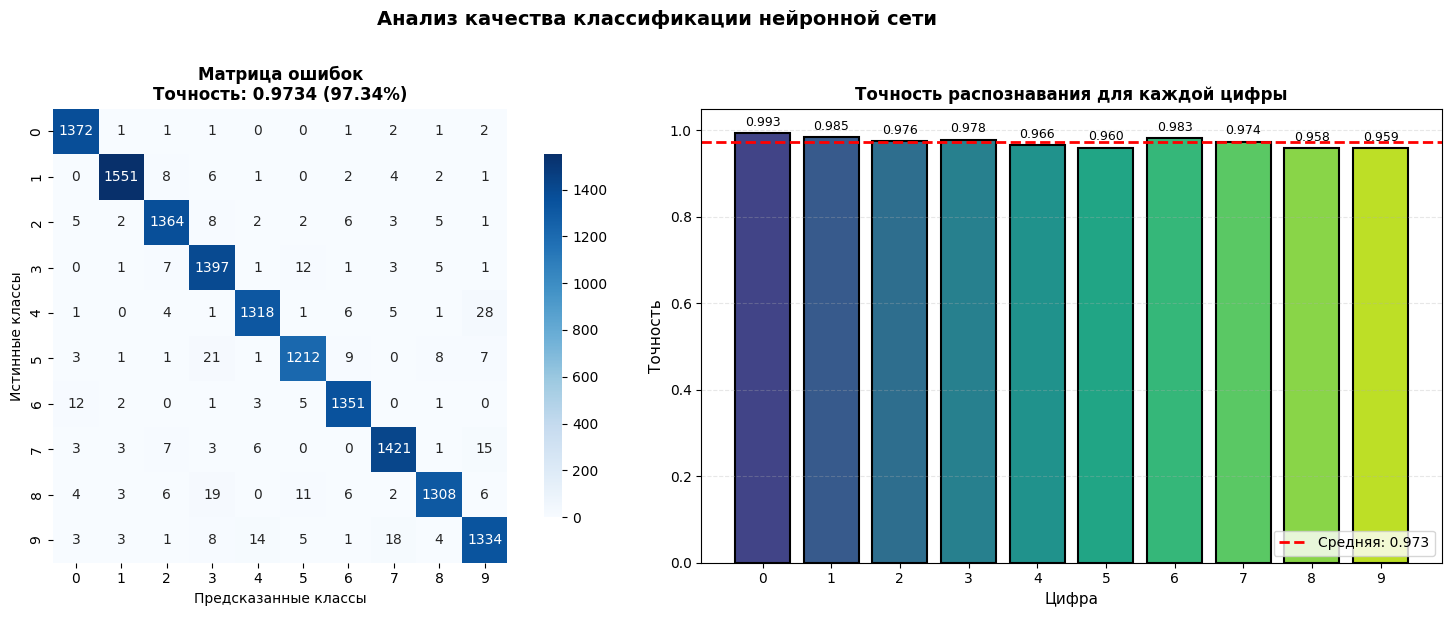

In [28]:
mlp_cm = confusion_matrix(y_test, mlp_predictions)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={"shrink": 0.8}, square=True,
            annot_kws={'size': 10})
ax1.set_title(f'Матрица ошибок\nТочность: {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Предсказанные классы', fontsize=10)
ax1.set_ylabel('Истинные классы', fontsize=10)

ax2 = axes[1]
per_digit_accuracy = []
for digit in range(10):
    digit_mask = (y_test == digit)
    digit_acc = accuracy_score(y_test[digit_mask], mlp_predictions[digit_mask])
    per_digit_accuracy.append(digit_acc)

colors = plt.cm.viridis(np.linspace(0.2, 0.9, 10))
bars = ax2.bar(range(10), per_digit_accuracy, color=colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=mlp_accuracy, color='red', linestyle='--', linewidth=2,
            label=f'Средняя: {mlp_accuracy:.3f}')
ax2.set_xlabel('Цифра', fontsize=11)
ax2.set_ylabel('Точность', fontsize=11)
ax2.set_title('Точность распознавания для каждой цифры', fontsize=12, fontweight='bold')
ax2.set_xticks(range(10))
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(alpha=0.3, axis='y', linestyle='--')

for bar, acc in zip(bars, per_digit_accuracy):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle("Анализ качества классификации нейронной сети",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()